In [1]:
# Cell 1
import os
import shutil
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
# Cell 1
import kagglehub
import os

path = kagglehub.dataset_download(
    "mohammadhossein77/brain-tumors-dataset"
)

print("Raw path:", path)
print("Contents:", os.listdir(path))


Using Colab cache for faster access to the 'brain-tumors-dataset' dataset.
Raw path: /kaggle/input/brain-tumors-dataset
Contents: ['Data']


In [3]:
# Cell 2
dataset_path = os.path.join(path, "/root/.cache/kagglehub/datasets/mohammadhossein77/brain-tumors-dataset/versions/3")

print("Final dataset path:", dataset_path)
print("Final contents:", os.listdir(dataset_path))


Final dataset path: /root/.cache/kagglehub/datasets/mohammadhossein77/brain-tumors-dataset/versions/3
Final contents: ['Data']


In [4]:
# Cell 3
dataset_path = os.path.join(dataset_path, "Data")

print("Correct dataset path:", dataset_path)
print("Contents:", os.listdir(dataset_path))


Correct dataset path: /root/.cache/kagglehub/datasets/mohammadhossein77/brain-tumors-dataset/versions/3/Data
Contents: ['Tumor', 'Normal']


In [5]:
# Cell 3
classes = ["Normal", "Glioma", "Meningioma", "Pituitary"]


In [6]:
# Cell 4
source_map = {
    "Normal": os.path.join(dataset_path, "Normal"),
    "Glioma": os.path.join(dataset_path, "Tumor", "glioma_tumor"),
    "Meningioma": os.path.join(dataset_path, "Tumor", "meningioma_tumor"),
    "Pituitary": os.path.join(dataset_path, "Tumor", "pituitary_tumor"),
}

for c, p in source_map.items():
    print(c, "->", len(os.listdir(p)), "images")


Normal -> 3066 images
Glioma -> 6307 images
Meningioma -> 6391 images
Pituitary -> 5908 images


In [7]:
# Cell 5
base_dir = "/content/brain_tumor_split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

for d in [train_dir, val_dir]:
    os.makedirs(d)

for c in classes:
    os.makedirs(os.path.join(train_dir, c))
    os.makedirs(os.path.join(val_dir, c))

print("Folders created")


Folders created


In [8]:
# Cell 6
for c in classes:
    images = [
        f for f in os.listdir(source_map[c])
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    train_imgs, val_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )

    for img in train_imgs:
        shutil.copy(
            os.path.join(source_map[c], img),
            os.path.join(train_dir, c)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(source_map[c], img),
            os.path.join(val_dir, c)
        )

print("Dataset split completed")


Dataset split completed


In [18]:
# Cell 1: إعداد المتغيرات الأساسية
IMAGE_SIZE = (224, 224)   # حجم الصور
BATCH_SIZE = 32           # حجم الباتش


In [19]:
# Cell 2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [20]:
# Cell 3
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 17335 images belonging to 4 classes.
Found 4337 images belonging to 4 classes.


In [21]:
# Cell 9
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False


In [22]:
# Cell 10
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])


In [23]:
# Cell 11
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [24]:
# Cell 12
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]


In [25]:
# Cell 13
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 273s 452ms/step - accuracy: 0.4888 - loss: 1.5856 - val_accuracy: 0.7867 - val_loss: 0.7716 - learning_rate: 1.0000e-04
Epoch 2/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 208s 383ms/step - accuracy: 0.6958 - loss: 0.9785 - val_accuracy: 0.8358 - val_loss: 0.6942 - learning_rate: 1.0000e-04
Epoch 3/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 212s 390ms/step - accuracy: 0.7434 - loss: 0.8720 - val_accuracy: 0.8575 - val_loss: 0.6535 - learning_rate: 1.0000e-04
Epoch 4/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 205s 378ms/step - accuracy: 0.7719 - loss: 0.8141 - val_accuracy: 0.8688 - val_loss: 0.6281 - learning_rate: 1.0000e-04
Epoch 5/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 213s 393ms/step - accuracy: 0.7921 - loss: 0.7710 - val_accuracy: 0.8743 - val_loss: 0.6157 - learning_rate: 1.0000e-04
Epoch 6/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 218s 401ms/step - accuracy: 0.8081 - loss: 0.7409 - val_accuracy: 0.8849 - val_loss: 0.6014 - learning_rate: 1.0000e-04
Epoch 7/15
542/542 ━━━━━━━━━━━━━━━━━━━━ 

In [26]:
# Cell 14 (UPDATED)
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False


In [27]:
# Cell 15 (UPDATED)
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss='categorical_crossentropy',   # نشيل label smoothing هنا
    metrics=['accuracy']
)


In [28]:
# Cell 16
history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 273s 447ms/step - accuracy: 0.7875 - loss: 0.5688 - val_accuracy: 0.8981 - val_loss: 0.2865 - learning_rate: 3.0000e-05
Epoch 2/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 218s 403ms/step - accuracy: 0.8629 - loss: 0.3687 - val_accuracy: 0.9175 - val_loss: 0.2369 - learning_rate: 3.0000e-05
Epoch 3/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 212s 392ms/step - accuracy: 0.8804 - loss: 0.3123 - val_accuracy: 0.9350 - val_loss: 0.1805 - learning_rate: 3.0000e-05
Epoch 4/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 209s 386ms/step - accuracy: 0.9039 - loss: 0.2607 - val_accuracy: 0.9412 - val_loss: 0.1635 - learning_rate: 3.0000e-05
Epoch 5/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 214s 394ms/step - accuracy: 0.9184 - loss: 0.2273 - val_accuracy: 0.9541 - val_loss: 0.1371 - learning_rate: 3.0000e-05
Epoch 6/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 212s 392ms/step - accuracy: 0.9310 - loss: 0.1968 - val_accuracy: 0.9580 - val_loss: 0.1194 - learning_rate: 3.0000e-05
Epoch 7/10
542/542 ━━━━━━━━━━━━━━━━━━━━ 

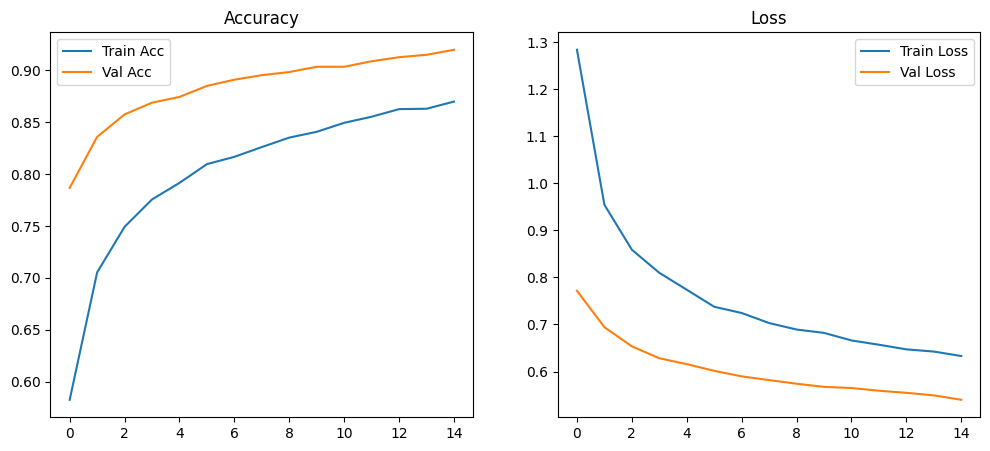

In [29]:
# Cell 11
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [30]:
# Cell 12
model.save('brain_tumor_classifier.h5')
print("Model saved successfully ✅")


Model saved successfully ✅


136/136 ━━━━━━━━━━━━━━━━━━━━ 28s 92ms/step
              precision    recall  f1-score   support

      Glioma       0.95      0.97      0.96      1262
  Meningioma       0.96      0.94      0.95      1279
      Normal       0.99      0.99      0.99       614
   Pituitary       0.98      0.98      0.98      1182

    accuracy                           0.97      4337
   macro avg       0.97      0.97      0.97      4337
weighted avg       0.97      0.97      0.97      4337



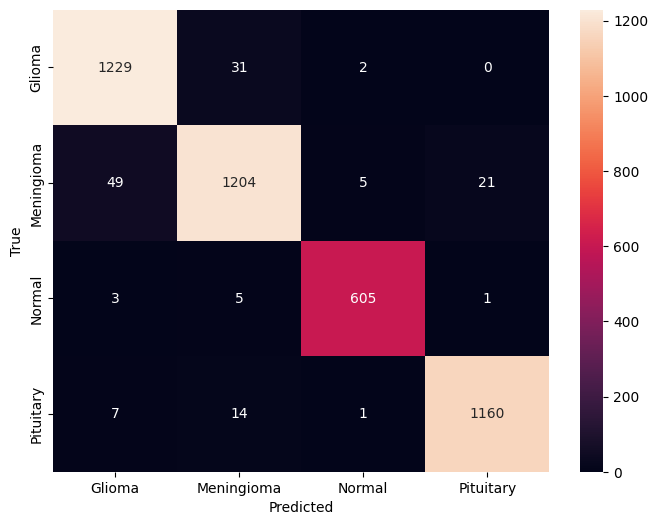

In [31]:
# Cell 13
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# التنبؤات
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=list(val_data.class_indices.keys())))

# Confusion matrix
import seaborn as sns
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(val_data.class_indices.keys()), yticklabels=list(val_data.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [42]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np

# رفع الصورة من جهازك
uploaded = files.upload()

# هيختار أول صورة مرفوعة تلقائيًا
img_path = list(uploaded.keys())[0]

# تحميل وتحويل الصورة
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

print(f"Uploaded and processed image: {img_path}")
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]
class_names = list(train_data.class_indices.keys())
pred_class = class_names[class_idx]

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred[0][class_idx]*100:.2f}%")

Saving image.webp to image (1).webp
Uploaded and processed image: image (1).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: Meningioma
Confidence: 99.92%


In [45]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np

# رفع الصورة من جهازك
uploaded = files.upload()

# هيختار أول صورة مرفوعة تلقائيًا
img_path = list(uploaded.keys())[0]

# تحميل وتحويل الصورة
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

print(f"Uploaded and processed image: {img_path}")
pred = model.predict(img_array)
class_idx = np.argmax(pred, axis=1)[0]
class_names = list(train_data.class_indices.keys())
pred_class = class_names[class_idx]

print(f"Predicted class: {pred_class}")
print(f"Confidence: {pred[0][class_idx]*100:.2f}%")

Saving images.jpeg to images (1).jpeg
Uploaded and processed image: images (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted class: Glioma
Confidence: 67.74%
